In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import os
import numpy as np

## File Prepping

In [2]:
results = [] # File Loading

path = './Results/Entire_Transformation_Matrix_W'

try:
    for filename in os.listdir(path):
        if filename in [".DS_Store", "Ablation_Results.csv", "Linear_Probe_Augmentation_Results.csv"]:
            continue
        file_path = os.path.join(path, filename)
        if os.path.isfile(file_path):
            results.append(file_path)
except FileNotFoundError:
    print(f"Error: The Folder '{path}' was not found.")
except Exception as e:
    print(f"An error occured: {e}")

In [3]:
len(results) # Should be 22. Sanity Check

42

In [4]:
data = [pd.read_csv(i) for i in results]
data = sorted(data, key=lambda df: df.loc[0, "Train_Data_Size"])

# Columns
'''
data = {
    'Train_Data_Size': [train_size]*len(indices),
    "Transformation": [type if type != "" else "None"] * len(indices),
    'W': [W[i] for i in indices], # data.loc[0, "W"] -> First layer transformation
    'b': [b[i] for i in indices],
    'Accuracy': [correct[i] for i in indices], 
    "Co_Sim_CLS": [sim_cls[i] for i in indices],
}
'''

'\ndata = {\n    \'Train_Data_Size\': [train_size]*len(indices),\n    "Transformation": [type if type != "" else "None"] * len(indices),\n    \'W\': [W[i] for i in indices], # data.loc[0, "W"] -> First layer transformation\n    \'b\': [b[i] for i in indices],\n    \'Accuracy\': [correct[i] for i in indices], \n    "Co_Sim_CLS": [sim_cls[i] for i in indices],\n}\n'

In [5]:
data[0].loc[2, "CLS_Cosine_Similarity"]

0.3454152542480462

## Classification Acccuracy and Cosine Similarity Graphs

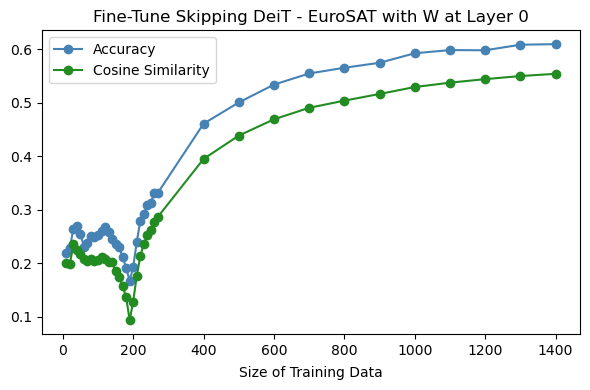

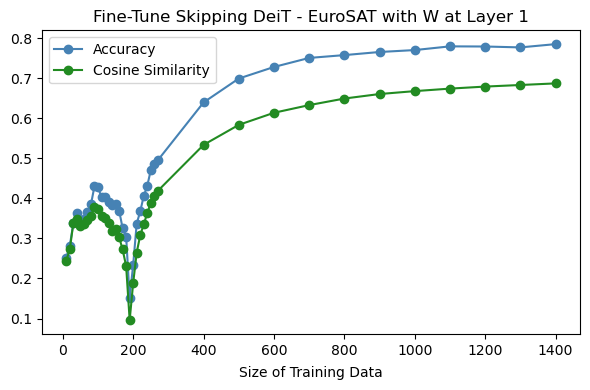

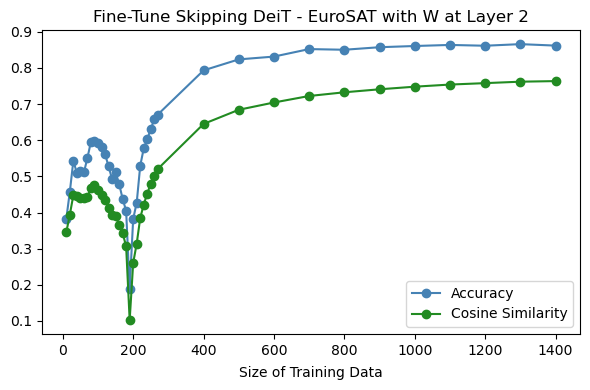

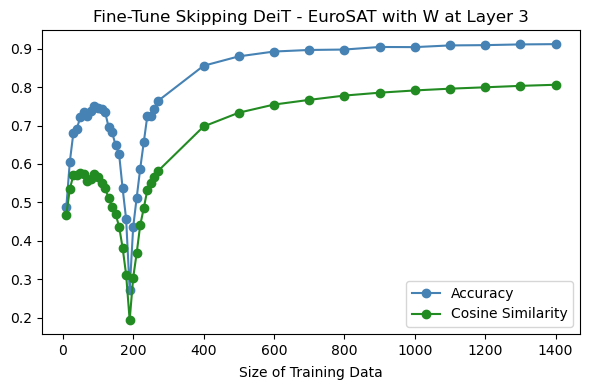

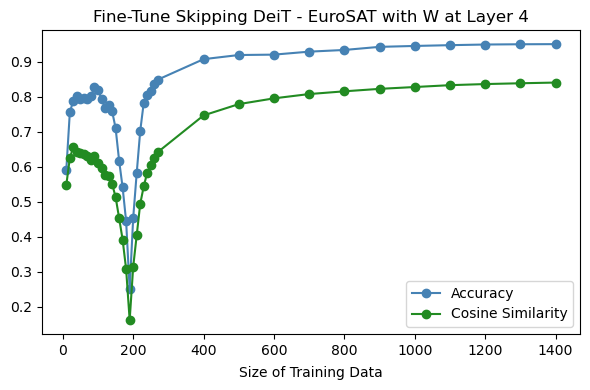

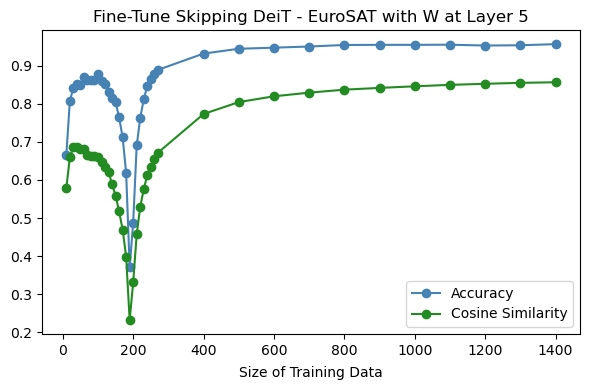

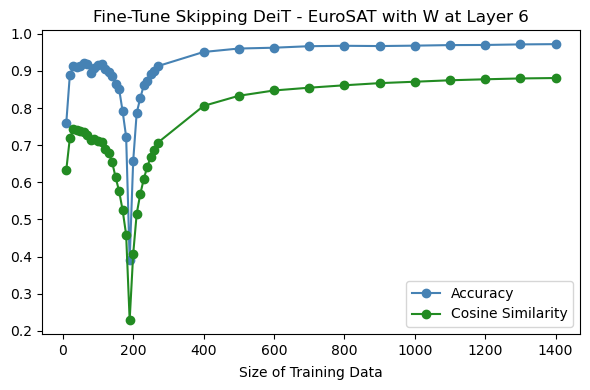

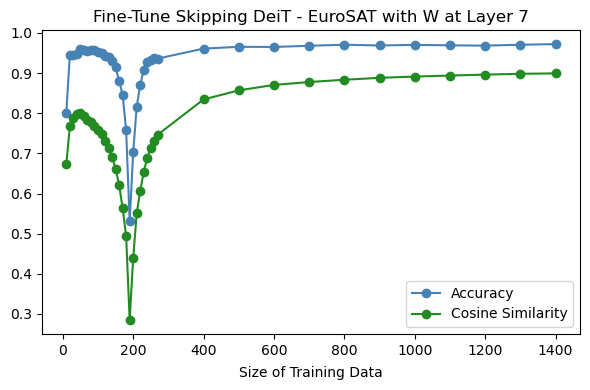

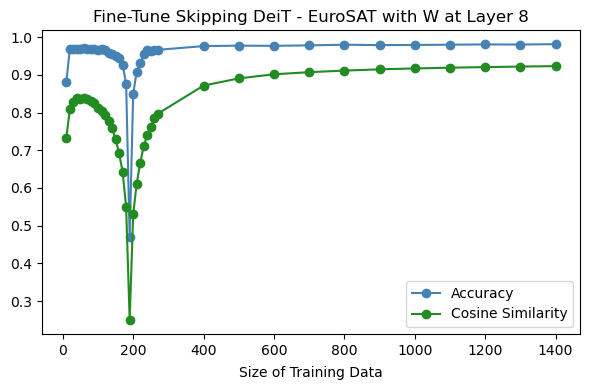

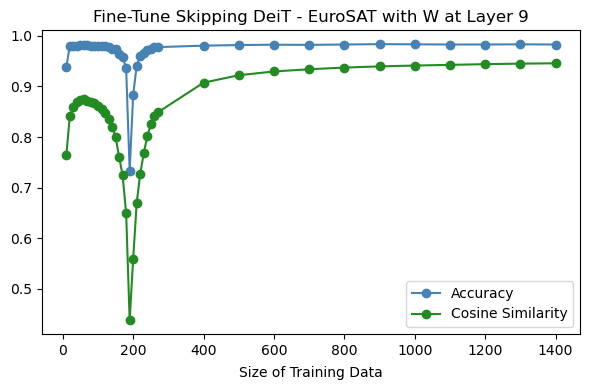

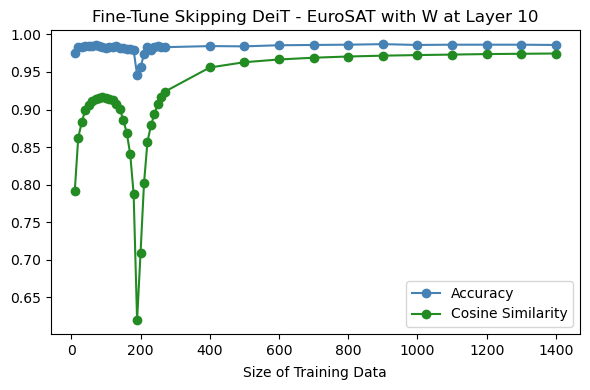

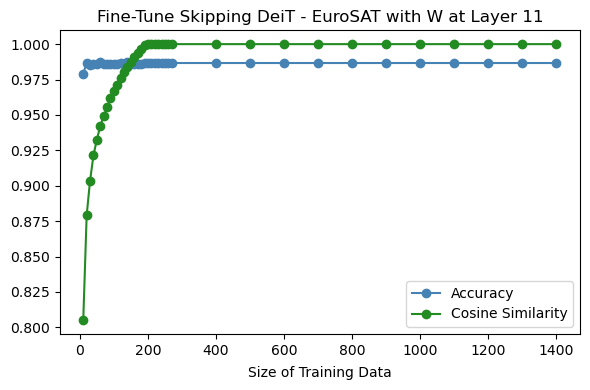

In [19]:
nrows = 2
ncols = 12

indices = [i for i in range(12)]

# figure, axes = plt.subplots(nrows, ncols)
for i in indices: # For Each Layer
    plt.figure(figsize=(6,4))
    train_size = []
    acc = []
    co_sim_cls = []
    for j in range(38): # For Each File
        train_size.append(data[j].loc[i, "Train_Data_Size"])
        acc.append(data[j].loc[i, "Classification_Accuracy"])
        co_sim_cls.append(data[j].loc[i, "CLS_Cosine_Similarity"])
    
    plt.plot(train_size, acc, marker='o', color='steelblue', label="Accuracy")
    plt.plot(train_size, co_sim_cls, marker='o', color="forestgreen", label="Cosine Similarity")
    plt.legend()
    plt.title(f"Fine-Tune Skipping DeiT - EuroSAT with W at Layer {i}")
    plt.xlabel("Size of Training Data", labelpad=6)
    plt.tight_layout()
    plt.savefig(f'./Graphed_Results/Augmented_Layer_{i}', dpi=600)
    plt.show()

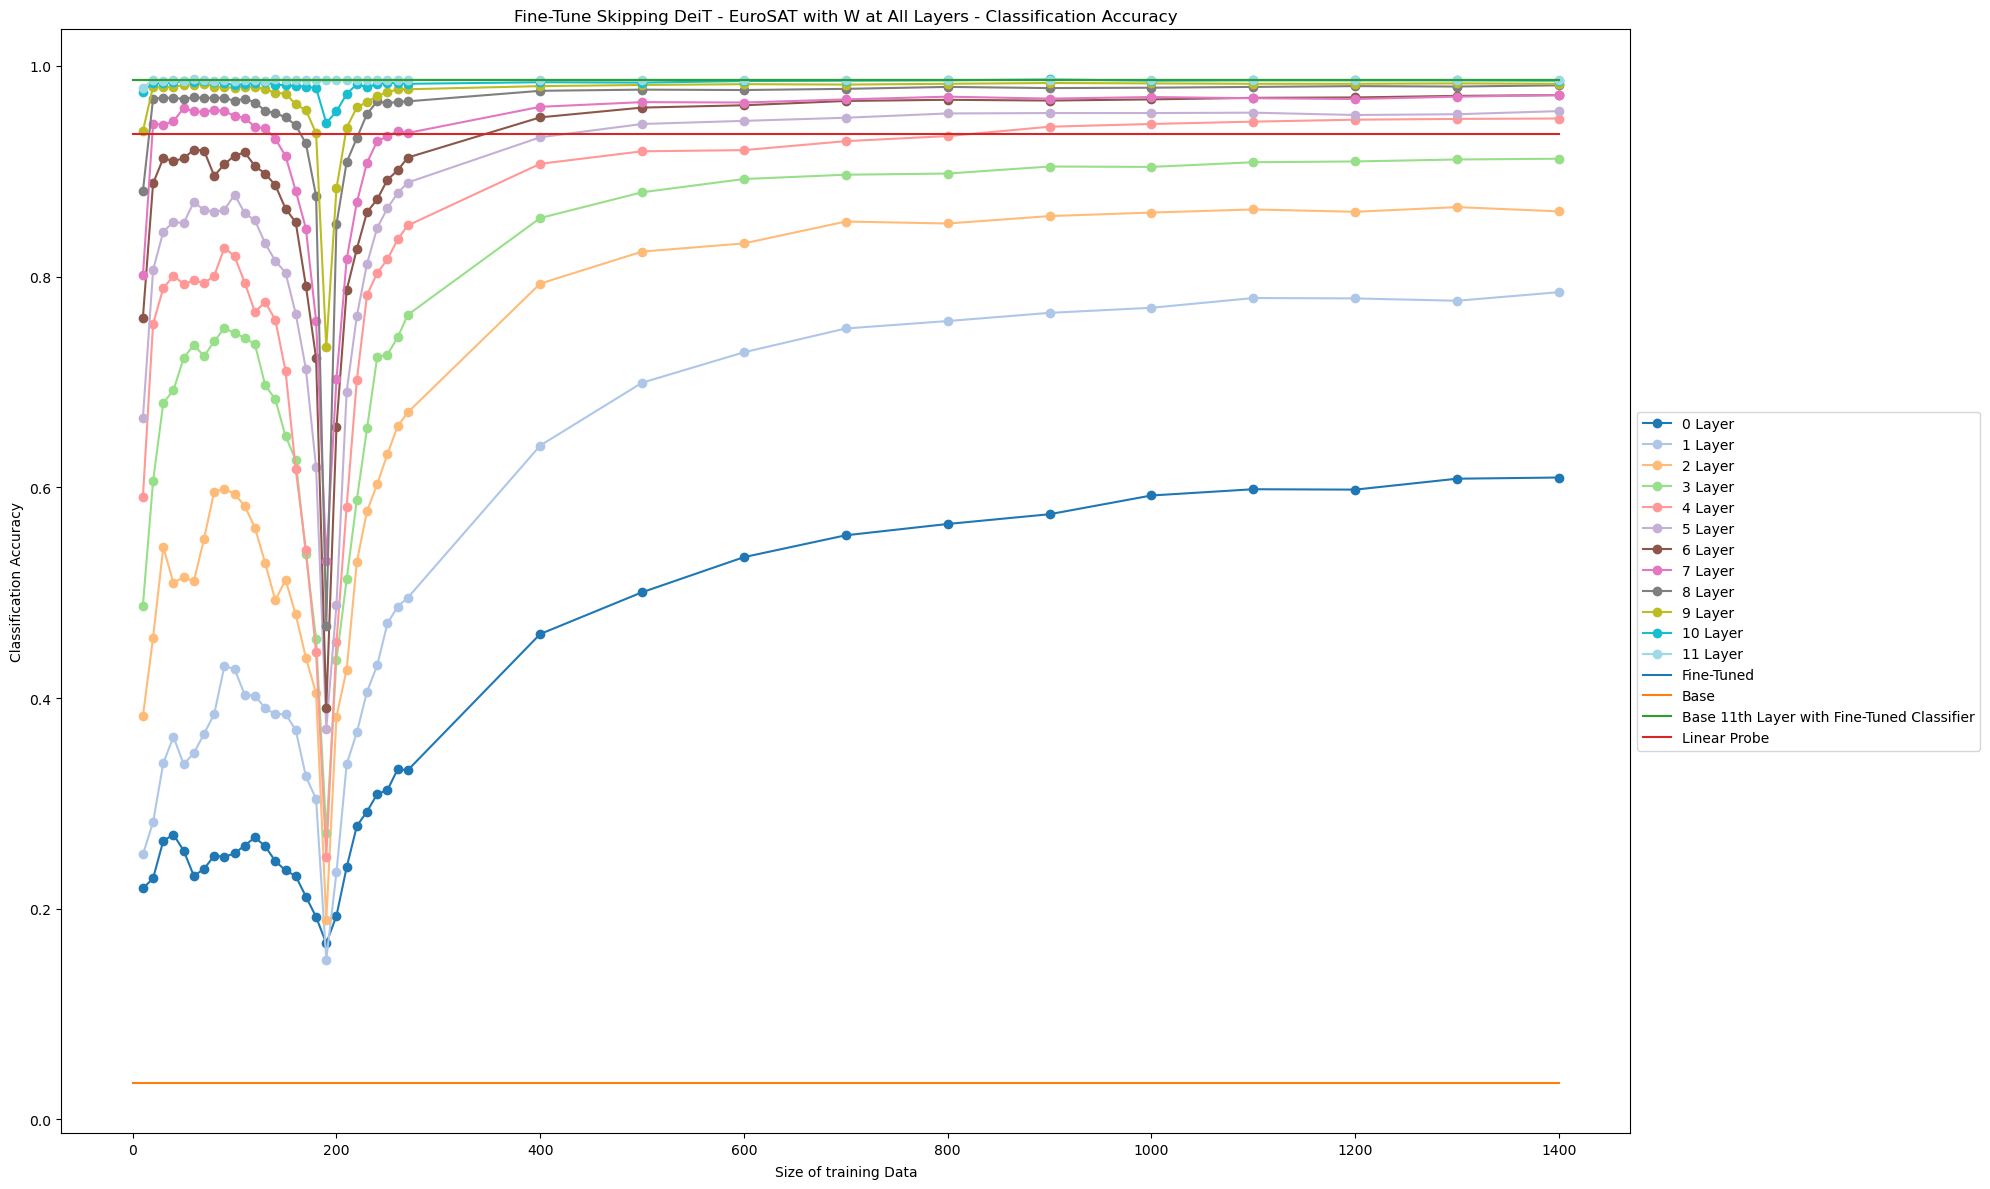

In [20]:
# All Accuracy Together
train_size = []
for i in range(38):
    train_size.append(data[i].loc[0, "Train_Data_Size"])
acc_vals = {}
for i in indices:
    acc_vals[i] = []
for i in indices:
    for j in range(38):
        acc_vals[i].append(data[j].loc[i, "Classification_Accuracy"])

colors = plt.cm.tab20(np.linspace(0,1,12))
plt.figure(figsize=(20,12))
for i in range(12):
    plt.plot(train_size, acc_vals[i], marker="o", color=colors[i], label=f"{i} Layer")
length = data[37].loc[0, "Train_Data_Size"]
plt.plot([0, length], [0.9867, 0.9867], label="Fine-Tuned")
plt.plot([0, length], [0.0348, 0.0348], label="Base")
plt.plot([0, length], [0.9866666666666667, 0.9866666666666667], label="Base 11th Layer with Fine-Tuned Classifier")
plt.plot([0, length], [0.9356, 0.9356], label="Linear Probe")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Fine-Tune Skipping DeiT - EuroSAT with W at All Layers - Classification Accuracy")
plt.xlabel("Size of training Data", labelpad=6)
plt.ylabel("Classification Accuracy")
plt.tight_layout()
plt.savefig(f'./Graphed_Results/All_Augmented_Layers_Classifiction_Accuracy', dpi=600)
plt.show()

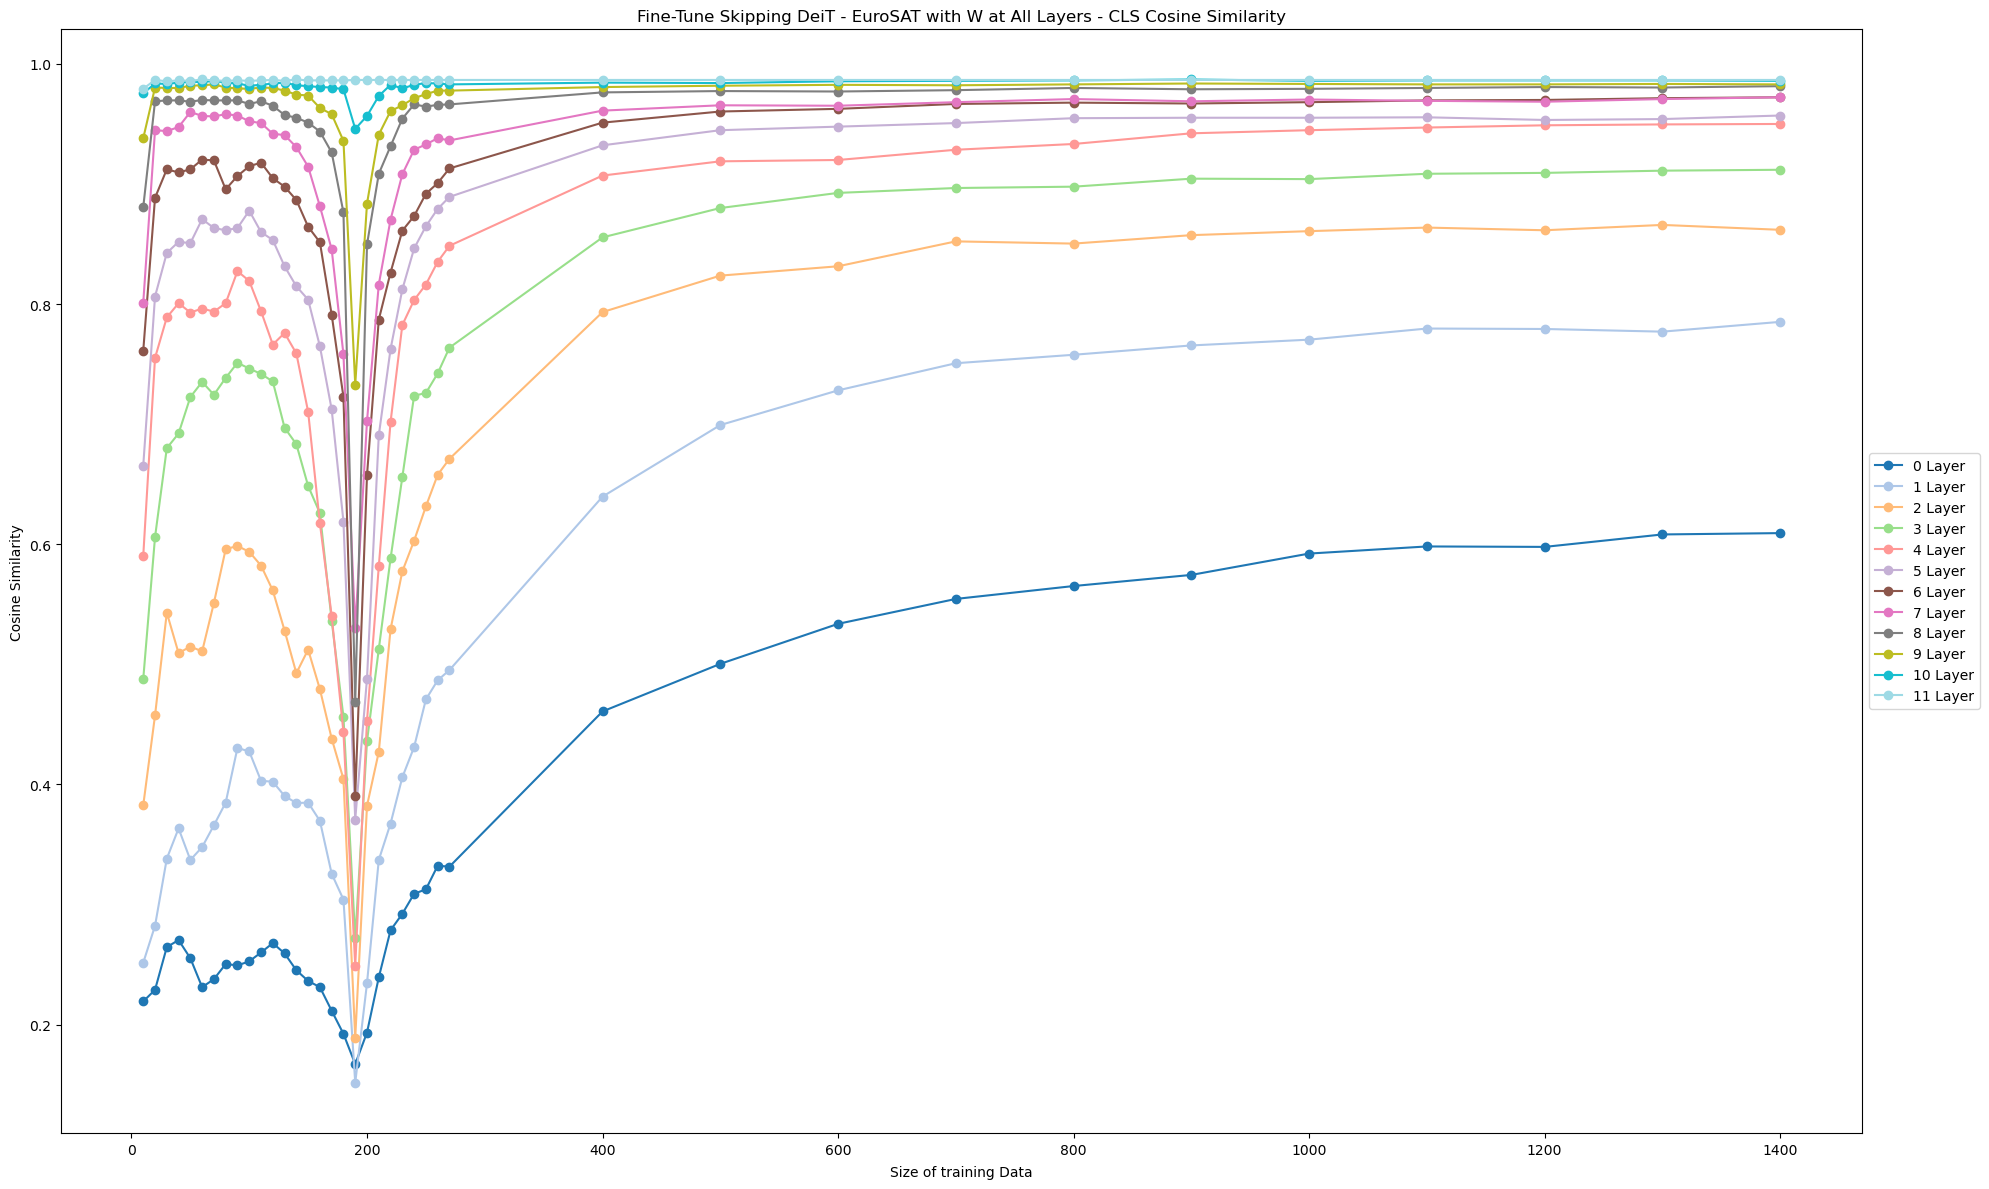

In [21]:
train_size = []
for i in range(38):
    train_size.append(data[i].loc[0, "Train_Data_Size"])
cls_vals = {}
for i in indices:
    cls_vals[i] = []
for i in indices:
    for j in range(38):
        cls_vals[i].append(data[j].loc[i, "CLS_Cosine_Similarity"])

colors = plt.cm.tab20(np.linspace(0,1,12))
plt.figure(figsize=(20,12))
for i in indices:
    plt.plot(train_size, acc_vals[i], marker="o", color=colors[i], label=f"{i} Layer")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Fine-Tune Skipping DeiT - EuroSAT with W at All Layers - CLS Cosine Similarity")
plt.xlabel("Size of training Data", labelpad=6)
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.savefig(f'./Graphed_Results/All_Augmented_Layers_CLS_Cosine_Similarity', dpi=600)
plt.show()

## Ablation Graphs

In [22]:
results = []
path = './Results/Entire_Transformation_Matrix_W'

try:
    for filename in os.listdir(path):
        if filename not in ["Ablation_Results.csv", "Transformation_Matrix_W_17280_Augmentation_Results.csv", "Linear_Probe_Augmentation_Results.csv"]:
            continue
        file_path = os.path.join(path, filename)
        if os.path.isfile(file_path):
            results.append(file_path)
except FileNotFoundError:
    print(f"Error: The Folder '{path}' was not found.")
except Exception as e:
    print(f"An error occured: {e}")

In [23]:
len(results)

3

In [24]:
results = [pd.read_csv(i) for i in results]

In [25]:
acc = []

acc_aug = []

linear_probe = []

for i in indices:
    linear_probe.append(results[1].loc[i, "Classification_Accuracy"])
    acc_aug.append(results[2].loc[i, "Classification_Accuracy"])
    acc.append(results[0].loc[i, "Classification_Accuracy"])

In [26]:
for i in linear_probe:
    print(i)

0.1111111111111111
0.0859259259259259
0.0959259259259259
0.0959259259259259
0.0796296296296296
0.15
0.2025925925925926
0.3118518518518518
0.7285185185185186
0.7733333333333333
0.7992592592592592
0.7718518518518519


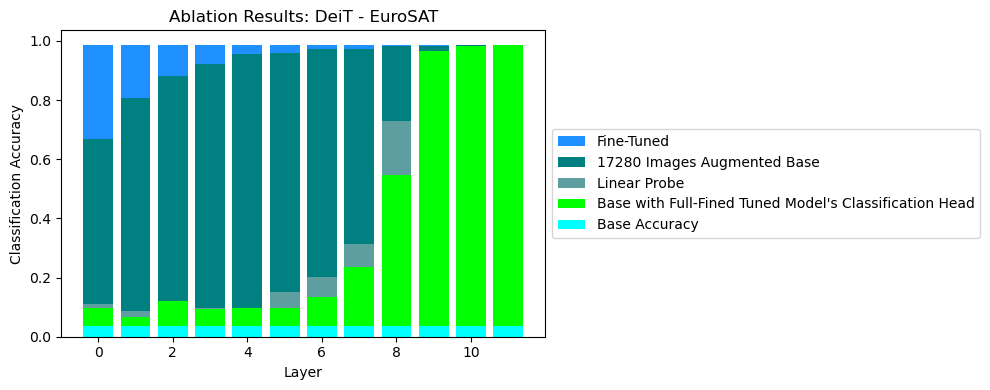

In [35]:
plt.figure(figsize=(10,4))

# plt.bar([i for i in range(12)], co_sim_cls, color="forestgreen", label="Cosine Similarity")
plt.bar([i for i in indices], 0.9867, color="dodgerblue", label="Fine-Tuned")
plt.bar([i for i in indices], acc_aug, color="teal", label="17280 Images Augmented Base")
plt.bar([i for i in indices], linear_probe, color="cadetblue", label="Linear Probe")
plt.bar([i for i in indices], acc, color="lime", label="Base with Full-Fined Tuned Model's Classification Head")
plt.bar([i for i in indices], 0.0348, color="cyan", label="Base Accuracy")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title(f"Ablation Results: DeiT - EuroSAT")
plt.xlabel("Layer")
plt.ylabel("Classification Accuracy")
plt.tight_layout()
plt.savefig(f'./Graphed_Results/Ablation_Classification_Accuracy', dpi=600)
plt.show()

## Residual Graphs

In [29]:
residuals = {}

for i in indices:
    residuals[i] = []
    for j in range(38):
        data_val = data[j].loc[i, "Residuals"]
        data_val = data_val.strip("[]").split()
        arr = np.array(data_val, dtype=float)
        residuals[i].append(arr)

In [30]:
data_size = []
for i in range(38):
    data_size.append(data[i].loc[0, "Train_Data_Size"])

In [31]:
print(len(residuals[0]))
print(residuals[0][16].shape)

38
(0,)


In [ ]:
# Instead of each being a vector of 768 dimensions, I reduce it to a single scalar for MSE 

In [32]:
residuals_mse = {}
for i in indices:
    residuals_mse[i] = []
    for j in range(38):
        vector = residuals[i][j]
        train_data_size = data[j].loc[i, "Train_Data_Size"]
        dimensions = vector.shape
        mse = sum(vector) / (train_data_size * dimensions[0])
        residuals_mse[i].append(mse)

/var/folders/_s/7xp5t6x10k14mhjn0lp95hfc0000gn/T/ipykernel_82004/903673527.py:8: RuntimeWarning: invalid value encountered in scalar divide
  mse = sum(vector) / (train_data_size * dimensions[0])


In [33]:
print(residuals_mse[0][16])

nan


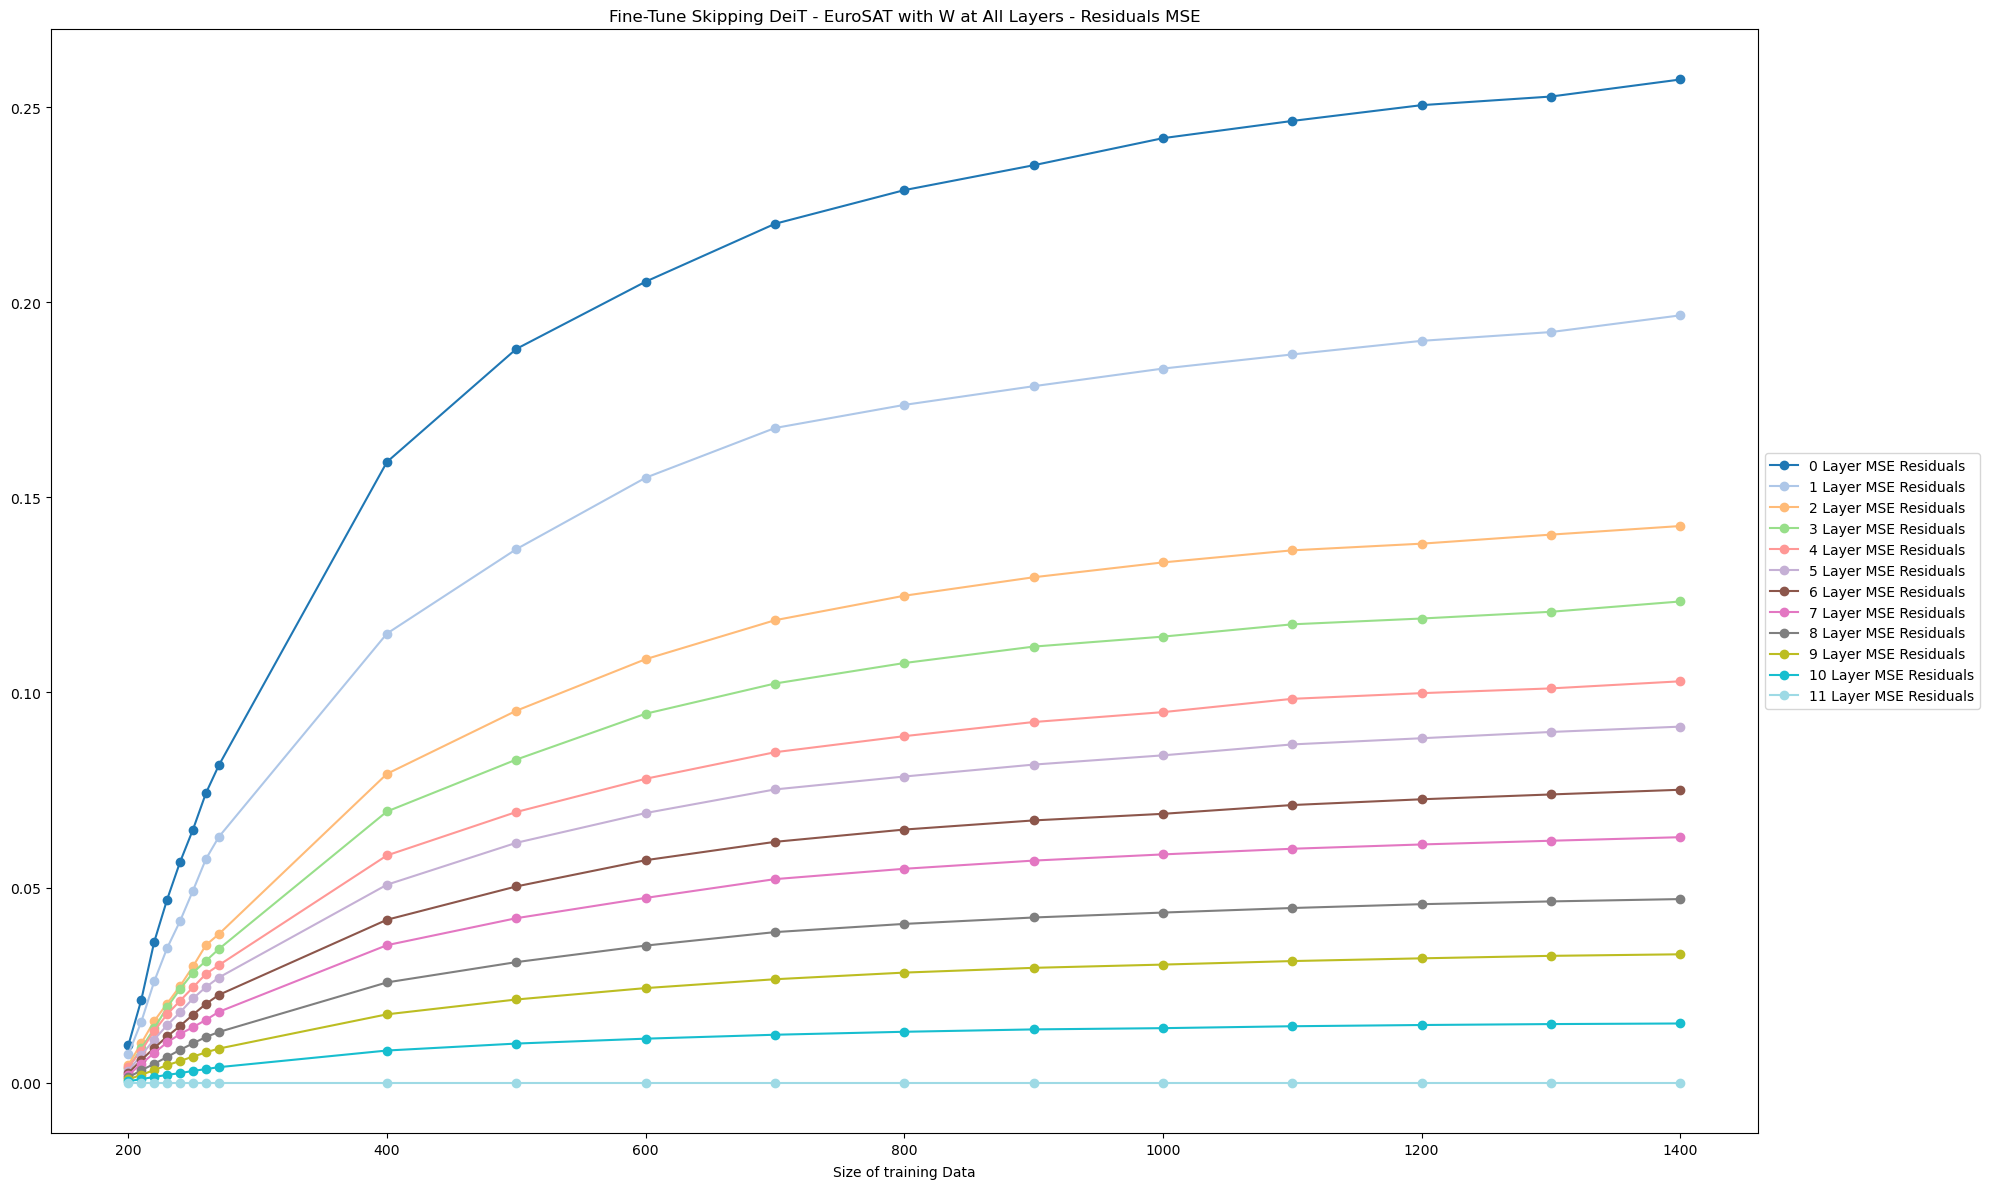

In [34]:
plt.figure(figsize=(20,12))
colors = plt.cm.tab20(np.linspace(0,1,12))
for i in indices:
    plt.plot(data_size, residuals_mse[i], marker="o", color=colors[i], label=f"{i} Layer MSE Residuals")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Fine-Tune Skipping DeiT - EuroSAT with W at All Layers - Residuals MSE")
plt.xlabel("Size of training Data", labelpad=6)
plt.tight_layout()
plt.savefig(f'./Graphed_Results/All_Augmented_Layers_Residuals', dpi=600)
plt.show()